# 01 · Exploración de los datos

Este notebook muestra de forma simple las series que descarga el proyecto desde las APIs del Banco Central de Chile (BCCh) y de FRED.

**Antes de ejecutarlo**, descarga los datos desde la terminal (en la raíz del proyecto):

```bash
python extraccion/E_BCCH.py
python extraccion/E_FRED.py
```

El notebook lee automáticamente **todos** los CSV de `data/raw/bcch/` y `data/raw/fred/`, así que al agregar nuevas series al script de extracción aparecerán aquí sin cambiar el código.

## 1. Librerías y ubicación de los datos

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Busca la raíz del proyecto (la carpeta que contiene requirements.txt),
# así el notebook funciona sin importar desde dónde se abra.
RAIZ = Path.cwd()
while not (RAIZ / "requirements.txt").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent

CARPETA_DATOS = RAIZ / "data" / "raw"
# Cada fuente guarda sus CSV en su propia subcarpeta: data/raw/bcch/ y data/raw/fred/
archivos = sorted(CARPETA_DATOS.glob("*/*.csv"))

if not archivos:
    raise FileNotFoundError(
        f"No hay CSV en {CARPETA_DATOS}/bcch ni {CARPETA_DATOS}/fred. "
        "Ejecuta primero: python extraccion/E_BCCH.py y python extraccion/E_FRED.py"
    )

print(f"Se encontraron {len(archivos)} series en {CARPETA_DATOS.relative_to(RAIZ)}:")
for a in archivos:
    print("  -", a.relative_to(CARPETA_DATOS))

Se encontraron 13 series en data/raw:
  - bcch/desempleo.csv
  - bcch/dolar_observado.csv
  - bcch/expectativa_ipc_eee.csv
  - bcch/imacec.csv
  - bcch/ipc.csv
  - bcch/ipc_sae.csv
  - bcch/tasa_bcp_10.csv
  - bcch/tasa_bcu_10.csv
  - bcch/tpm.csv
  - fred/fed_funds.csv
  - fred/ipc_eeuu.csv
  - fred/precio_cobre.csv
  - fred/produccion_industrial_eeuu.csv


## 2. Carga de las series

Cada CSV tiene las columnas `fecha`, `valor`, `serie` y `codigo`. Se juntan todas en una sola tabla en formato **largo** (una fila por serie y fecha), que es el mismo formato que usaremos después en la base de datos SQL. dsfdsfs

In [2]:
datos = pd.concat(
    # La columna "fuente" indica de dónde viene cada serie (nombre de la subcarpeta: bcch o fred)
    [pd.read_csv(a, parse_dates=["fecha"]).assign(fuente=a.parent.name) for a in archivos],
    ignore_index=True,
)

# Cada serie debe tener un nombre único entre ambas fuentes, si no la tabla ancha se mezcla
repetidas = datos.groupby("serie")["fuente"].nunique().loc[lambda s: s > 1]
if not repetidas.empty:
    raise ValueError(f"Series con el mismo nombre en dos fuentes: {list(repetidas.index)}")

datos.head()

,fecha,valor,serie,codigo,fuente
0,2010-03-01,9.227598,desempleo,F049.DES.TAS.INE9.10.M,bcch
1,2010-04-01,8.836054,desempleo,F049.DES.TAS.INE9.10.M,bcch
2,2010-05-01,9.087731,desempleo,F049.DES.TAS.INE9.10.M,bcch
3,2010-06-01,8.656064,desempleo,F049.DES.TAS.INE9.10.M,bcch
4,2010-07-01,8.511179,desempleo,F049.DES.TAS.INE9.10.M,bcch


## 3. Ficha resumen de cada serie

Para cada serie: su fuente, su código (BDE o FRED), el período que cubre, cuántas observaciones tiene, cuántas faltan y su último valor disponible.

In [3]:
def resumir(grupo):
    grupo = grupo.sort_values("fecha")
    ultimo = grupo.dropna(subset=["valor"]).iloc[-1]
    return pd.Series({
        "fuente": grupo["fuente"].iloc[0],
        "codigo": grupo["codigo"].iloc[0],
        "desde": grupo["fecha"].min().strftime("%Y-%m"),
        "hasta": grupo["fecha"].max().strftime("%Y-%m"),
        "observaciones": len(grupo),
        "faltantes": int(grupo["valor"].isna().sum()),
        "ultimo_valor": round(ultimo["valor"], 2),
        "fecha_ultimo_valor": ultimo["fecha"].strftime("%Y-%m"),
    })

resumen = datos.groupby("serie").apply(resumir, include_groups=False).sort_values(["fuente", "desde"])
resumen

,fuente,codigo,desde,hasta,observaciones,faltantes,ultimo_valor,fecha_ultimo_valor
serie,,,,,,,,
dolar_observado,bcch,F073.TCO.PRE.HIST.M,2000-01,2026-09,321,0,947.27,2026-09
imacec,bcch,F032.IMC.IND.Z.Z.EP18.Z.Z.0.M,2000-01,2026-08,320,0,109.08,2026-08
ipc,bcch,F074.IPC.VAR.Z.Z.C.M,2000-01,2026-09,321,0,0.40,2026-09
tpm,bcch,F022.TPM.TIN.D001.NO.Z.M,2000-01,2026-09,321,0,4.50,2026-09
expectativa_ipc_eee,bcch,F089.IPC.V12.14.M,2001-01,2026-09,309,7,3.30,2026-09
tasa_bcu_10,bcch,F022.BUF.TIS.AN10.UF.Z.D,2002-09,2026-10,290,0,2.78,2026-10
tasa_bcp_10,bcch,F022.BCP.TIN.AN10.NO.Z.D,2004-07,2013-08,110,57,5.26,2013-08
desempleo,bcch,F049.DES.TAS.INE9.10.M,2010-03,2026-08,198,0,9.64,2026-08
ipc_sae,bcch,F074.IPCSAE.VAR.Z.2023.C.M,2023-02,2026-09,44,0,0.10,2026-09


## 4. Vista de los datos

La misma información en formato **ancho**: una columna por serie y una fila por mes. Se muestran los últimos 12 meses.

In [4]:
tabla = datos.pivot(index="fecha", columns="serie", values="valor")
tabla.tail(12).round(2)

serie,desempleo,dolar_observado,expectativa_ipc_eee,fed_funds,imacec,ipc,ipc_eeuu,ipc_sae,precio_cobre,produccion_industrial_eeuu,tasa_bcp_10,tasa_bcu_10,tpm
fecha,,,,,,,,,,,,,
2025-11-01,8.42,935.70,3.2,3.88,118.45,0.3,325.06,0.4,10812.03,101.03,NaN,2.34,4.75
2025-12-01,8.05,916.16,3.0,3.72,129.20,-0.2,326.03,-0.1,11790.96,101.49,NaN,2.33,4.64
2026-01-01,8.28,883.97,3.0,3.64,111.21,0.4,326.59,0.7,12986.61,101.04,NaN,2.32,4.50
2026-02-01,8.33,862.02,3.0,3.64,104.40,0.0,327.46,0.1,12951.34,101.91,NaN,2.32,4.50
2026-03-01,8.93,909.89,3.0,3.64,120.37,1.0,330.29,0.8,12528.71,101.73,NaN,2.18,4.50
2026-04-01,9.11,897.89,4.0,3.64,114.36,1.3,332.41,0.3,12890.69,102.58,NaN,2.13,4.50
2026-05-01,9.44,897.64,3.3,3.63,112.11,0.2,333.98,0.4,13512.16,102.64,NaN,2.29,4.50
2026-06-01,9.44,903.38,3.1,3.63,110.60,0.0,332.57,-0.1,13552.04,102.84,NaN,2.47,4.50
2026-07-01,9.53,930.97,3.0,3.63,106.97,0.1,332.81,0.4,13542.82,103.05,NaN,2.48,4.50


## 5. Evolución de cada serie

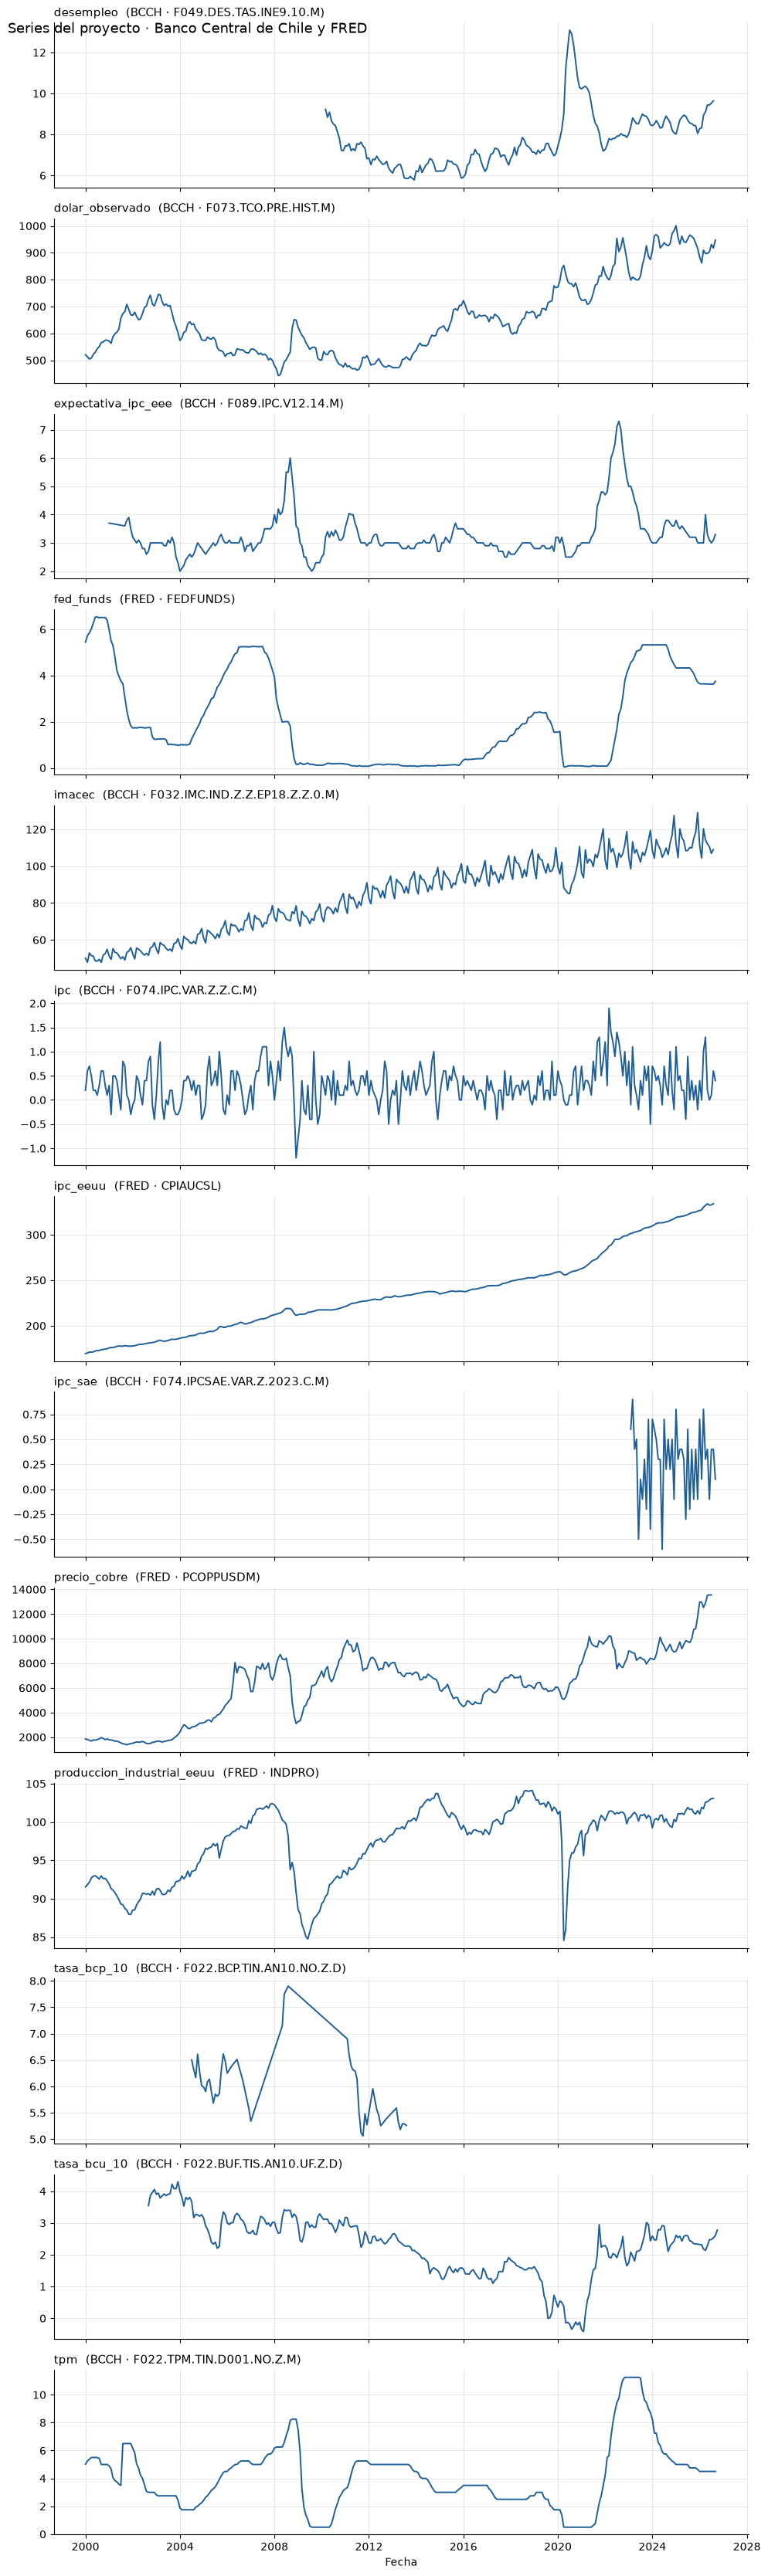

In [5]:
series = tabla.columns
fig, ejes = plt.subplots(
    nrows=len(series), ncols=1,
    figsize=(10, 2.6 * len(series)),
    sharex=True, squeeze=False,
)

for eje, nombre in zip(ejes[:, 0], series):
    s = tabla[nombre].dropna()
    eje.plot(s.index, s.values, color="#1f5f99", linewidth=1.4)
    eje.set_title(f"{nombre}  ({resumen.loc[nombre, 'fuente'].upper()} · {resumen.loc[nombre, 'codigo']})", loc="left", fontsize=11)
    eje.grid(alpha=0.3)
    eje.spines[["top", "right"]].set_visible(False)

ejes[-1, 0].set_xlabel("Fecha")
fig.suptitle("Series del proyecto · Banco Central de Chile y FRED", fontsize=13, x=0.01, ha="left")
fig.tight_layout()
plt.show()

## Próximos pasos

- Agregar el resto de las series al diccionario `SERIES` de `extraccion/E_BCCH.py` o `extraccion/E_FRED.py` y volver a ejecutar este notebook.
- Cargar estos datos a la base de datos SQLite (tablas de catálogo, observaciones y clasificación temática).